## 1.Nạp thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

## 2.Nạp dữ liệu

In [3]:
dataset = pd.read_csv('/content/drive/MyDrive/2321004059_PhanHongPhuc_KPDL/Chuong4/7.Apriori/Data/Market_Basket.csv',header=None)
dataset.head(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
dataset.info()
#dữ liệu được thu thập trong vòng 1 tuần và người ta cho biết trước có 3 giao dịch/1 khách hàng/1 ngày
#vậy min_support được ước tính = 3*7ngay/7500 = 0.0028

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       7501 non-null   object
 1   1       5747 non-null   object
 2   2       4389 non-null   object
 3   3       3345 non-null   object
 4   4       2529 non-null   object
 5   5       1864 non-null   object
 6   6       1369 non-null   object
 7   7       981 non-null    object
 8   8       654 non-null    object
 9   9       395 non-null    object
 10  10      256 non-null    object
 11  11      154 non-null    object
 12  12      87 non-null     object
 13  13      47 non-null     object
 14  14      25 non-null     object
 15  15      8 non-null      object
 16  16      4 non-null      object
 17  17      4 non-null      object
 18  18      3 non-null      object
 19  19      1 non-null      object
dtypes: object(20)
memory usage: 1.1+ MB


In [4]:
dataset.values

array([['shrimp', 'almonds', 'avocado', ..., 'frozen smoothie',
        'spinach', 'olive oil'],
       ['burgers', 'meatballs', 'eggs', ..., nan, nan, nan],
       ['chutney', nan, nan, ..., nan, nan, nan],
       ...,
       ['chicken', nan, nan, ..., nan, nan, nan],
       ['escalope', 'green tea', nan, ..., nan, nan, nan],
       ['eggs', 'frozen smoothie', 'yogurt cake', ..., nan, nan, nan]],
      dtype=object)

In [5]:
#Xử lý phần từ NaN
trans_arr = [ [ str(item) for item in trans if str(item) !='nan' ] for trans in dataset.values] #list conprehension

In [6]:
trans_arr[:2]

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs']]

## 3.Trực quan hóa tần suất xuất hiện của top 10 item

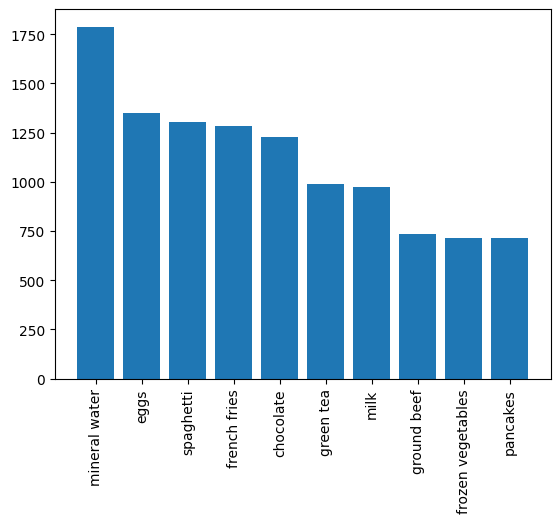

In [12]:
all_items = [ item  for tran in trans_arr for item in tran  ]
#all_items[:2]
item_freq = pd.Series(all_items).value_counts()
#item_freq[:5]

top10_item = item_freq.head(10)

plt.bar(top10_item.index,top10_item.values)
plt.xticks(rotation=90)
plt.show()

## 4.Mã hóa giao dịch (Transaction Encoder)

In [15]:
transac_en = TransactionEncoder()
transac_en_arr = transac_en.fit(trans_arr).transform(trans_arr)

df_transac_en = pd.DataFrame(transac_en_arr,columns=transac_en.columns_)
df_transac_en

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,bramble,brownies,bug spray,burger sauce,burgers,butter,cake,candy bars,carrots,cauliflower,cereals,champagne,chicken,chili,chocolate,chocolate bread,chutney,cider,clothes accessories,cookies,cooking oil,corn,cottage cheese,cream,dessert wine,eggplant,eggs,energy bar,energy drink,...,oil,olive oil,pancakes,parmesan cheese,pasta,pepper,pet food,pickles,protein bar,red wine,rice,salad,salmon,salt,sandwich,shallot,shampoo,shrimp,soda,soup,spaghetti,sparkling water,spinach,strawberries,strong cheese,tea,tomato juice,tomato sauce,tomatoes,toothpaste,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

## 5.Huấn luyện mô hình apriori

In [18]:
#b1 tìm tập phổ biến
freq_items = apriori(df_transac_en,min_support=0.0028,use_colnames=True) #tìm ra các tập phổ biến dựa trên thuật toán apriori


In [19]:
freq_items #tập phổ biến

,support,itemsets
0,0.020397,(almonds)
1,0.008932,(antioxydant juice)
2,0.004666,(asparagus)
3,0.033329,(avocado)
4,0.004533,(babies food)
...,...,...
1522,0.002933,"(mineral water, ground beef, spaghetti, shrimp)"
1523,0.003066,"(mineral water, ground beef, spaghetti, tomatoes)"
1524,0.003333,"(olive oil, mineral water, milk, spaghetti)"
1525,0.003066,"(mineral water, milk, spaghetti, shrimp)"


In [35]:
# B2. Sinh luật
from mlxtend.frequent_patterns import association_rules
rules = association_rules(freq_items,metric='confidence',min_threshold=0.2) #đặt nhỏ để không bỏ sót luật
display(rules)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(almonds),(burgers),0.020397,0.087188,0.005199,0.254902,2.923577,1.0,0.003421,1.225089,0.671653,0.050781,0.183733,0.157267
1,(almonds),(chocolate),0.020397,0.163845,0.005999,0.294118,1.795099,1.0,0.002657,1.184553,0.452150,0.033657,0.155800,0.165366
2,(almonds),(eggs),0.020397,0.179709,0.006532,0.320261,1.782108,1.0,0.002867,1.206774,0.448005,0.033747,0.171344,0.178306
3,(almonds),(french fries),0.020397,0.170911,0.004399,0.215686,1.261983,1.0,0.000913,1.057089,0.211919,0.023538,0.054006,0.120714
4,(almonds),(green tea),0.020397,0.132116,0.005066,0.248366,1.879913,1.0,0.002371,1.154663,0.477806,0.034358,0.133947,0.143356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,"(mineral water, milk, spaghetti)",(tomatoes),0.015731,0.068391,0.003333,0.211864,3.097846,1.0,0.002257,1.182042,0.688018,0.041254,0.154006,0.130299
1461,"(mineral water, milk, tomatoes)",(spaghetti),0.006532,0.174110,0.003333,0.510204,2.930353,1.0,0.002196,1.686192,0.663076,0.018797,0.406948,0.264673
1462,"(mineral water, tomatoes, spaghetti)",(milk),0.009332,0.129583,0.003333,0.357143,2.756099,1.0,0.002124,1.353982,0.643171,0.024582,0.261438,0.191432
1463,"(tomatoes, milk, spaghetti)",(mineral water),0.005866,0.238368,0.003333,0.568182,2.383631,1.0,0.001935,1.763779,0.583897,0.013835,0.433036,0.291082


In [36]:
top5_confidence = rules.nlargest(5,columns='confidence')
top5_confidence

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1415,"(frozen vegetables, soup, milk)",(mineral water),0.003999,0.238368,0.003066,0.766667,3.216312,1.0,0.002113,3.264136,0.691852,0.012813,0.693640,0.389765
1358,"(eggs, cooking oil, spaghetti)",(mineral water),0.004133,0.238368,0.002933,0.709677,2.977232,1.0,0.001948,2.623398,0.666874,0.012243,0.618815,0.360991
1410,"(frozen vegetables, milk, olive oil)",(mineral water),0.004799,0.238368,0.003333,0.694444,2.913326,1.0,0.002189,2.492613,0.659917,0.013897,0.598815,0.354213
452,"(cereals, ground beef)",(spaghetti),0.004533,0.174110,0.003066,0.676471,3.885303,1.0,0.002277,2.552751,0.746001,0.017464,0.608266,0.347041
1396,"(frozen vegetables, milk, ground beef)",(mineral water),0.005733,0.238368,0.003733,0.651163,2.731752,1.0,0.002366,2.183344,0.637590,0.015530,0.541987,0.333411


In [37]:
#lọc ra các luật vế trái chỉ có 1 item và vế phải chỉ 1 item
filter_rules = rules[
  (rules['antecedents'].apply(lambda x: len(x)) == 1 ) &
  (rules['consequents'].apply(lambda x: len(x)) == 1 )
 ]

In [38]:
filter_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(almonds),(burgers),0.020397,0.087188,0.005199,0.254902,2.923577,1.0,0.003421,1.225089,0.671653,0.050781,0.183733,0.157267
1,(almonds),(chocolate),0.020397,0.163845,0.005999,0.294118,1.795099,1.0,0.002657,1.184553,0.452150,0.033657,0.155800,0.165366
2,(almonds),(eggs),0.020397,0.179709,0.006532,0.320261,1.782108,1.0,0.002867,1.206774,0.448005,0.033747,0.171344,0.178306
3,(almonds),(french fries),0.020397,0.170911,0.004399,0.215686,1.261983,1.0,0.000913,1.057089,0.211919,0.023538,0.054006,0.120714
4,(almonds),(green tea),0.020397,0.132116,0.005066,0.248366,1.879913,1.0,0.002371,1.154663,0.477806,0.034358,0.133947,0.143356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,(vegetables mix),(spaghetti),0.025730,0.174110,0.005599,0.217617,1.249879,1.0,0.001119,1.055608,0.205202,0.028826,0.052678,0.124888
290,(white wine),(spaghetti),0.016531,0.174110,0.004533,0.274194,1.574828,1.0,0.001654,1.137893,0.371146,0.024355,0.121183,0.150114
291,(whole wheat pasta),(spaghetti),0.029463,0.174110,0.008799,0.298643,1.715251,1.0,0.003669,1.177559,0.429654,0.045175,0.150786,0.174589
292,(whole wheat rice),(spaghetti),0.058526,0.174110,0.014131,0.241458,1.386811,1.0,0.003942,1.088786,0.296260,0.064674,0.081546,0.161311
